# MLP Classification




## Learning goals

- Understand the matrix operations inside an MLP.
- Train and evaluate a reproducible classifier.
- Save preprocessing and the model together in a pipeline.
- Inspect weights, biases, scaling parameters, and predictions.
- Connect the Python implementation to an Excel or mathematical implementation.
- Evaluate a model using evidence rather than only a single accuracy number.

## Part 1: Load and understand the data

The Palmer Penguins dataset contains measurements of three penguin species. Before modeling, inspect the variables, missing values, class balance, and units.

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
None

Missing values:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Class counts:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


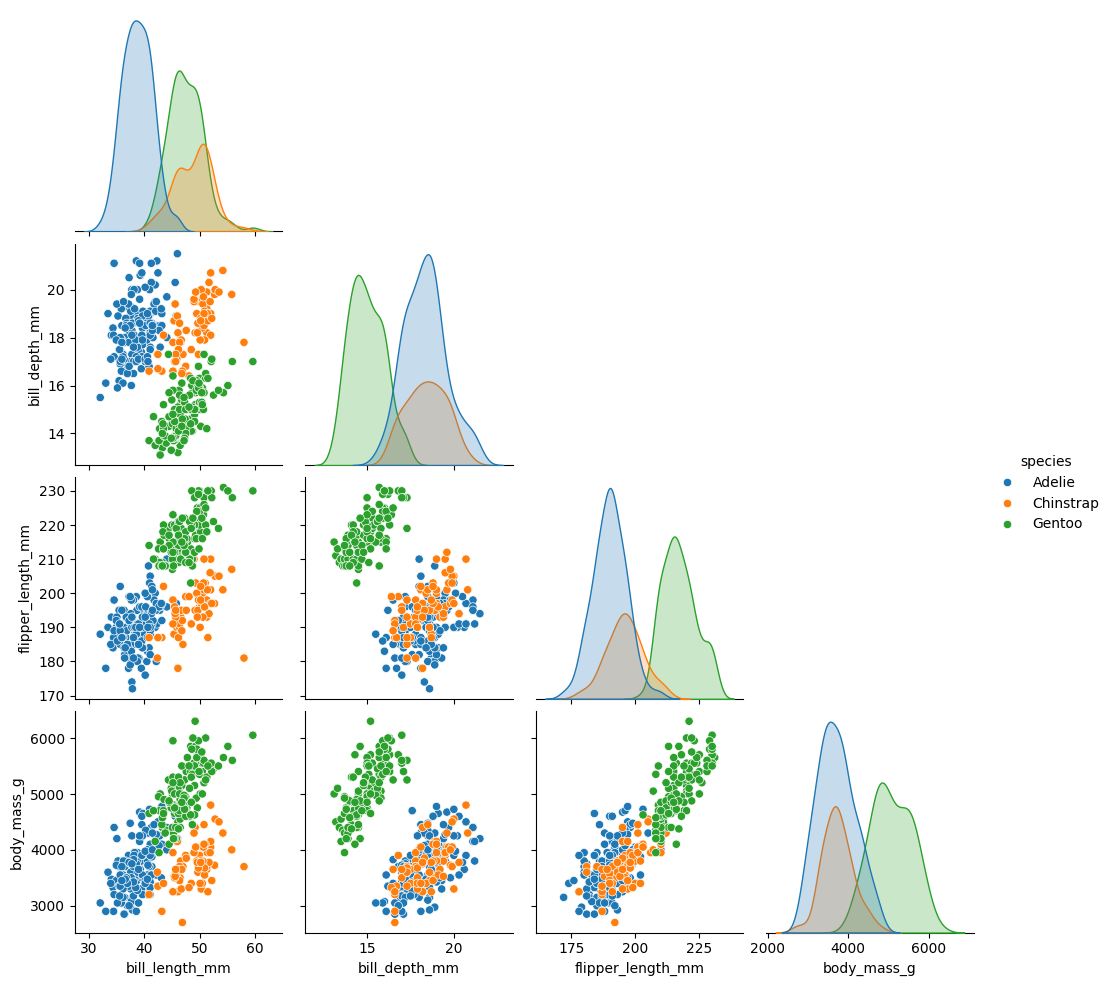

In [31]:
print(penguins.info())
print("\nMissing values:")
print(penguins.isna().sum())
print("\nClass counts:")
print(penguins["species"].value_counts())

sns.pairplot(penguins, hue="species", corner=True)
plt.show()

## Part 2: Prepare features without losing reproducibility

We remove incomplete rows and encode the two categorical variables. The pipeline will standardize numeric columns during training. Keeping preprocessing inside the pipeline prevents applying a different transformation during prediction.

In [32]:
penguins = penguins.dropna().copy()

X = penguins.drop(columns=["species"])
y = penguins["species"]

X["sex"] = X["sex"].map({"Male": 0, "Female": 1})
X["island"] = X["island"].map({"Biscoe": 0, "Dream": 1, "Torgersen": 2})

print(X.dtypes)
X.head()

island                 int64
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                    int64
dtype: object


,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,2,39.1,18.7,181.0,3750.0,0
1,2,39.5,17.4,186.0,3800.0,1
2,2,40.3,18.0,195.0,3250.0,1
4,2,36.7,19.3,193.0,3450.0,1
5,2,39.3,20.6,190.0,3650.0,0


## Part 3: Train and evaluate an MLP pipeline

An MLP applies affine transformations and nonlinear activation functions. Here, `StandardScaler` and `MLPClassifier` are stored as one object.

Accuracy: 1.0
F1 macro: 1.0
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        51
   Chinstrap       1.00      1.00      1.00        24
      Gentoo       1.00      1.00      1.00        42

    accuracy                           1.00       117
   macro avg       1.00      1.00      1.00       117
weighted avg       1.00      1.00      1.00       117

best_params_: {'classifier__activation': 'relu', 'classifier__hidden_layer_sizes': (20, 10)}
Mejor score en validación cruzada: 0.9906976744186047
Accuracy: 1.0
F1 macro: 1.0
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        51
   Chinstrap       1.00      1.00      1.00        24
      Gentoo       1.00      1.00      1.00        42

    accuracy                           1.00       117
   macro avg       1.00      1.00      1.00       117
weighted avg       1.00      1.00      1.00       117

                     Modelo  Accura

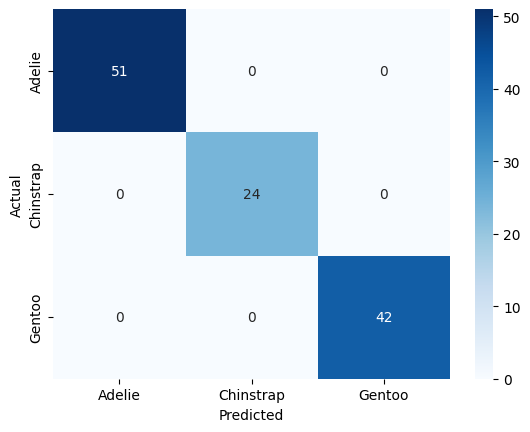

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

RANDOM_STATE = 7
TEST_SIZE = 0.35
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
model_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(20, 10),
        activation="relu",
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

model_pipeline.fit(X_train, y_train)
y_pred_baseline = model_pipeline.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline, average="macro")
print("Accuracy:", baseline_accuracy)
print("F1 macro:", baseline_f1)
print(classification_report(y_test, y_pred_baseline))
param_grid = {
    "classifier__hidden_layer_sizes": [(20, 10), (10,), (30, 15), (50,)],
    "classifier__activation": ["relu", "tanh"]
}

grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("best_params_:", grid_search.best_params_)
print("best_score_:", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred_optimized = best_model.predict(X_test)

optimized_accuracy = accuracy_score(y_test, y_pred_optimized)
optimized_f1 = f1_score(y_test, y_pred_optimized, average="macro")

print("Accuracy:", optimized_accuracy)
print("F1 macro:", optimized_f1)
print(classification_report(y_test, y_pred_optimized))

comparison = pd.DataFrame({
    "Modelo": ["Base (20,10) relu", f"Optimizado {grid_search.best_params_['classifier__hidden_layer_sizes']} {grid_search.best_params_['classifier__activation']}"],
    "Accuracy (test)": [baseline_accuracy, optimized_accuracy],
    "F1 macro (test)": [baseline_f1, optimized_f1],
    "CV score": [None, grid_search.best_score_]
})

print(comparison)

conf = confusion_matrix(y_test, y_pred_optimized)
sns.heatmap(
    conf, annot=True, cmap="Blues",
    xticklabels=best_model.classes_,
    yticklabels=best_model.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [51]:
best_model = grid_search.best_estimator_

best_scaler = best_model.named_steps["scaler"]
best_classifier = best_model.named_steps["classifier"]
print(best_scaler)
print(best_classifier)

StandardScaler()
MLPClassifier(hidden_layer_sizes=(20, 10), max_iter=1000, random_state=7)


In [52]:
feature_names = list(X.columns)

scaler_parameters = pd.DataFrame({
    "Feature": feature_names,
    "Mean": best_scaler.mean_,
    "Scale": best_scaler.scale_
})

print(scaler_parameters)

             Feature         Mean       Scale
0             island     0.625000    0.702591
1     bill_length_mm    43.998611    5.403578
2      bill_depth_mm    17.184259    1.976747
3  flipper_length_mm   200.763889   13.396544
4        body_mass_g  4174.421296  796.874109
5                sex     0.518519    0.499657


In [53]:
model_classes = best_classifier.classes_

print("Clases del modelo:")
print(model_classes)

Clases del modelo:
['Adelie' 'Chinstrap' 'Gentoo']


In [54]:
classes_df = pd.DataFrame({
    "Class_Index": range(len(model_classes)),
    "Class": model_classes
})

print(classes_df)

   Class_Index      Class
0            0     Adelie
1            1  Chinstrap
2            2     Gentoo


In [55]:
weight_matrices = best_classifier.coefs_

print("Número de matrices de pesos:", len(weight_matrices))

for i, W in enumerate(weight_matrices):
    print(f"W{i+1}: {W.shape}")

Número de matrices de pesos: 3
W1: (6, 20)
W2: (20, 10)
W3: (10, 3)


In [56]:
bias_vectors = best_classifier.intercepts_

print("Número de vectores de bias:", len(bias_vectors))

for i, b in enumerate(bias_vectors):
    print(f"b{i+1}: {b.shape}")

Número de vectores de bias: 3
b1: (20,)
b2: (10,)
b3: (3,)


## Part 7: Export parameters for Excel

Exporting parameters is useful for learning and auditing. It is not the same as exporting a production-ready model: Excel must still reproduce scaling, matrix multiplication, ReLU, and softmax correctly.

In [57]:
excel_file = "best_mlp_parameters.xlsx"

with pd.ExcelWriter(excel_file) as writer:

    # 1. Guardar parámetros del StandardScaler
    scaler_parameters.to_excel(
        writer,
        sheet_name="Scaler",
        index=False
    )

    # 2. Guardar las clases
    classes_df.to_excel(
        writer,
        sheet_name="Classes",
        index=False
    )

    # 3. Guardar las matrices de pesos
    for i, W in enumerate(weight_matrices):

        weights_df = pd.DataFrame(W)

        weights_df.to_excel(
            writer,
            sheet_name=f"W{i+1}",
            index=False
        )

    # 4. Guardar los vectores de bias
    for i, b in enumerate(bias_vectors):

        bias_df = pd.DataFrame({
            "Bias": b
        })

        bias_df.to_excel(
            writer,
            sheet_name=f"b{i+1}",
            index=False
        )

print("Archivo Excel creado:")
print(excel_file)

Archivo Excel creado:
best_mlp_parameters.xlsx


In [58]:
import os

print("Carpeta actual:")
print(os.getcwd())

print("\nRuta completa del archivo:")
print(os.path.abspath("best_mlp_parameters.xlsx"))

Carpeta actual:
c:\Users\DETPC\Downloads

Ruta completa del archivo:
c:\Users\DETPC\Downloads\best_mlp_parameters.xlsx


In [59]:
# Seleccionar una observación del conjunto de prueba
observation = X_test.iloc[[0]]

print("Observación seleccionada:")
print(observation)
true_class = y_test.iloc[0]

print("Clase verdadera:")
print(true_class)

Observación seleccionada:
    island  bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  sex
43       1            44.1           19.7              196.0       4400.0    0
Clase verdadera:
Adelie


In [60]:
python_probabilities = best_model.predict_proba(observation)[0]

print("Probabilidades calculadas por Python:")
for class_name, prob in zip(best_classifier.classes_, python_probabilities):
    print(f"{class_name}: {prob:.6f}")

print("\nClase predicha por Python:")
print(best_model.predict(observation)[0])

Probabilidades calculadas por Python:
Adelie: 0.987166
Chinstrap: 0.012166
Gentoo: 0.000668

Clase predicha por Python:
Adelie


In [61]:
excel_probabilities = [
    0.99477,   # Adelie
    0.00322,   # Chinstrap
    0.00201    # Gentoo
]

In [62]:
comparison_probabilities = pd.DataFrame({
    "Class": best_classifier.classes_,
    "Excel_Probability": excel_probabilities,
    "Python_Probability": python_probabilities
})

comparison_probabilities["Difference"] = abs(
    comparison_probabilities["Excel_Probability"]
    - comparison_probabilities["Python_Probability"]
)

print(comparison_probabilities)

       Class  Excel_Probability  Python_Probability  Difference
0     Adelie            0.99477            0.987166    0.007604
1  Chinstrap            0.00322            0.012166    0.008946
2     Gentoo            0.00201            0.000668    0.001342
